# 인공지능수학 4주차 — 경사하강법(gradient descent)

**강의 시간:** 75분 (이론 60분 + 익히기 15분)

**지난 주 복습:**
- 선형회귀 모델: $\hat{\mathbf{y}} = X\mathbf{w}$
- MSE 손실함수: $\mathcal{L}(w) = \frac{1}{m}\sum(\hat{y}_i - y_i)^2$
- MSE는 $w$의 **이차함수** → 그릇 모양, 최솟값이 하나
- **열린 질문:** 이 최솟값을 어떻게 찾는가?

**이번 주 답:** 경사하강법

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

---
# 🪄 Aha! — 먼저 결과부터

손실 함수 위에서 학습률에 따라 최솟값을 찾아가는 경로가 어떻게 달라지는지 봅니다.

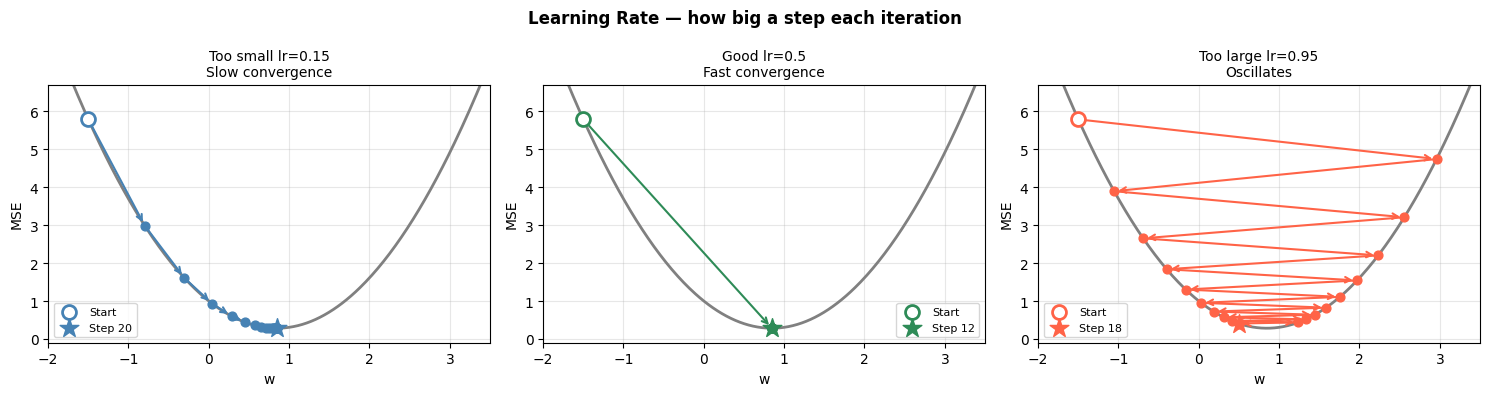

In [2]:
n = 40
area    = np.random.uniform(30, 130, n)
price   = 280*area + 5000 + np.random.randn(n)*6000
area_n  = (area  - area.mean())  / area.std()  #평균과 표준편차를 이용하여 표준화 후 활용
price_n = (price - price.mean()) / price.std() #평균과 표준편차를 이용하여 표준화 후 활용

def mse_1d(w):  return np.mean((w*area_n - price_n)**2)
def grad_1d(w): return 2*np.mean((w*area_n - price_n)*area_n)

def gd_path(lr, steps, w0=-1.5):
    w, path = w0, [w0]
    for _ in range(steps):
        w = w - lr*grad_1d(w)
        path.append(w)
        if abs(w) > 8: break
    return path

w_range    = np.linspace(-2, 3.5, 300)
loss_curve = [mse_1d(w) for w in w_range]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    (0.15, 20, 'Too small lr=0.15\nSlow convergence',  'steelblue'),
    (0.5,  12, 'Good lr=0.5\nFast convergence',        'seagreen'),
    (0.95, 18, 'Too large lr=0.95\nOscillates',        'tomato'),
]
for ax, (lr, steps, title, color) in zip(axes, configs):
    path   = gd_path(lr, steps)
    losses = [mse_1d(w) for w in path]
    ax.plot(w_range, loss_curve, color='gray', lw=2)
    for i in range(len(path)-1):
        ax.annotate('', xy=(path[i+1], losses[i+1]), xytext=(path[i], losses[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                                   shrinkA=3, shrinkB=3))
    ax.scatter(path, losses, color=color, s=40, zorder=5)
    ax.scatter(path[0],  losses[0],  color='white', edgecolors=color,
               s=100, zorder=6, lw=2, label='Start')
    ax.scatter(path[-1], losses[-1], color=color, marker='*',
               s=200, zorder=6, label=f'Step {len(path)-1}')
    ax.set_xlabel('w'); ax.set_ylabel('MSE')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-2, 3.5); ax.set_ylim(-0.1, max(loss_curve)*0.8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Learning Rate — how big a step each iteration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> ❓ **어떻게 각 위치에서 '내려가는 방향'을 알 수 있을까요?**
> 오늘 이 질문에 답합니다.

---
# Part 1. 미분 — 순간의 기울기

## 1-1. 미분의 의미

함수 $f(x)$의 **미분값** $f'(x)$는 그 점에서의 **순간 기울기**입니다.

| $f'(x)$ | 의미 |
|:---:|---|
| $> 0$ | 오른쪽으로 갈수록 증가 → 줄이려면 왼쪽으로 |
| $< 0$ | 오른쪽으로 갈수록 감소 → 줄이려면 오른쪽으로 |
| $= 0$ | 극값 (최솟값 후보) |

## 1-2. 다항함수 미분 공식

|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 함수 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;| &nbsp;&nbsp;미분 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;| &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;예시&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|---|---|---|
| $c$ (상수) | $0$ | $(5)' = 0$ |
| $x^n$ | $n x^{n-1}$ | $(x^3)' = 3x^2$ |
| $ax + b$ | $a$ | $(3x+2)' = 3$ |
| $ax^2 + bx + c$ | $2ax + b$ | $(2x^2-4x+1)' = 4x-4$ |

**최솟값 조건:** $f'(x^*) = 0$ 인 $x^*$ 가 최솟값 위치

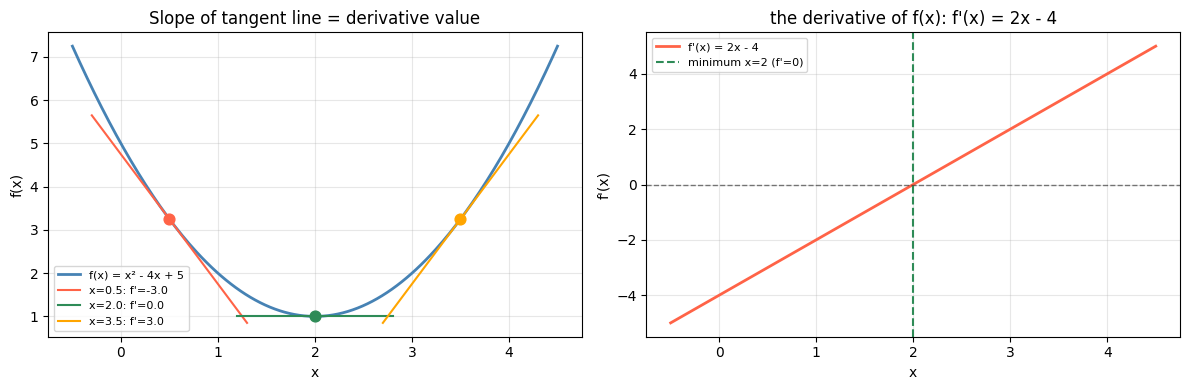

f'(x) = 0 → 2x - 4 = 0 → x* = 2
f(2) = 1  ← 최솟값


In [3]:
# Visualize derivative as slope of tangent line
def f(x):  return x**2 - 4*x + 5
def df(x): return 2*x - 4

x = np.linspace(-0.5, 4.5, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(x, f(x), color='steelblue', lw=2, label='f(x) = x² - 4x + 5')
for x0, color in [(0.5, 'tomato'), (2.0, 'seagreen'), (3.5, 'orange')]:
    slope = df(x0)
    x_tan = np.linspace(x0-0.8, x0+0.8, 50)
    ax.plot(x_tan, f(x0)+slope*(x_tan-x0), color=color, lw=1.5,
            label=f"x={x0}: f'={slope:.1f}")
    ax.scatter([x0], [f(x0)], color=color, s=60, zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Slope of tangent line = derivative value')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, df(x), color='tomato', lw=2, label="f'(x) = 2x - 4")
ax.axhline(0, color='black', lw=1, ls='--', alpha=0.5)
ax.axvline(2, color='seagreen', lw=1.5, ls='--', label='minimum x=2 (f\'=0)')
ax.set_xlabel('x'); ax.set_ylabel("f'(x)")
ax.set_title("the derivative of f(x): f'(x) = 2x - 4")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최솟값: f'(x*)=0 → 2x-4=0 → x*=2
print("f'(x) = 0 → 2x - 4 = 0 → x* = 2")
print(f"f(2) = {f(2)}  ← 최솟값")

## 1-3. 합성함수 미분 (Chain Rule)

함수 안에 함수가 있을 때:

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

**직관:** "바깥 함수 미분 × 안 함수 미분"

| &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 함수 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;분해&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | &nbsp;&nbsp;&nbsp;&nbsp;chain rule 적용&nbsp;&nbsp;&nbsp;&nbsp; |
|---|---|---|
| $(3x+1)^2$ | $f(u)=u^2$, $g(x)=3x+1$ | $2(3x+1) \cdot 3 = 6(3x+1)$ |
| $(wx - y)^2$ | $f(u)=u^2$, $g(w)=wx-y$ | $2(wx-y) \cdot x$ |

두 번째 줄이 바로 MSE gradient의 핵심입니다.

In [4]:
# Chain rule 검증
# (wx - y)^2 를 w에 대해 미분 → 2*(wx-y)*x

w_test, x_val, y_val = 0.5, 2.0, 3.0

# 수치 미분으로 확인 (h→0 근사)
h = 1e-7
numerical = ((w_test+h)*x_val - y_val)**2 - ((w_test-h)*x_val - y_val)**2
numerical /= 2*h

# Chain rule
analytical = 2*(w_test*x_val - y_val)*x_val

print(f"Chain rule:    d/dw (wx-y)^2 = 2*(wx-y)*x = {analytical:.6f}")
print(f"수치 미분:                                  = {numerical:.6f}")
print(f"일치: {np.isclose(analytical, numerical)}")

Chain rule:    d/dw (wx-y)^2 = 2*(wx-y)*x = -8.000000
수치 미분:                                  = -8.000000
일치: True


---
# Part 2. MSE의 Gradient

## 2-1. MSE를 w, b에 대해 미분

$$\mathcal{L}(w, b) = \frac{1}{m}\sum_{i=1}^m (wx_i + b - y_i)^2$$

$w$에 대한 편미분 — chain rule 적용:

$$\frac{\partial \mathcal{L}}{\partial w}
= \frac{1}{m}\sum_{i=1}^m \underbrace{2(wx_i+b-y_i)}_{\text{바깥: }2u} \cdot \underbrace{x_i}_{\text{안: }g'(w)}
= \frac{2}{m}\sum_{i=1}^m (\hat{y}_i - y_i)\,x_i$$

$b$에 대한 편미분 ($b$는 $x_i$가 없으므로 안 함수 미분 = 1):

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{2}{m}\sum_{i=1}^m (\hat{y}_i - y_i)$$

## 2-2. Gradient 직관

> 각 샘플에서 잔차 $\hat{y}_i - y_i$와 $x_i$​를 곱한 값은
[$w$를 조금 키웠을 때 이 샘플의 손실이 얼마나 늘어나는가]
 를 나타냄. 이것을 모든 샘플에 대해 더하면, 전체 손실을 줄이는 $w$의 이동 방향이 자동으로 결정

>잔차가 크면 gradient도 크다 → 많이 틀릴수록 더 크게 수정

In [5]:
# Gradient 계산
def gradient(w, b, X, y):
    m = len(y)
    y_hat = w*X + b
    dw = (2/m) * np.sum((y_hat - y) * X)
    db = (2/m) * np.sum(y_hat - y)
    return dw, db

# 몇 가지 점에서 gradient 확인
print("w=0.0 b=0.0 →", end=" ")
dw, db = gradient(0.0, 0.0, area_n, price_n)
print(f"dL/dw={dw:.4f}  dL/db={db:.4f}")

print("w=0.85 b=0.0 →", end=" ")   # near optimum
dw, db = gradient(0.85, 0.0, area_n, price_n)
print(f"dL/dw={dw:.4f}  dL/db={db:.4f}  ← 최솟값 근처, gradient ≈ 0")

w=0.0 b=0.0 → dL/dw=-1.6940  dL/db=-0.0000
w=0.85 b=0.0 → dL/dw=0.0060  dL/db=0.0000  ← 최솟값 근처, gradient ≈ 0


---
# Part 3. 경사하강법 (Gradient Descent)

## 3-1. 알고리즘

$$w_{t+1} = w_t - \alpha \frac{\partial \mathcal{L}}{\partial w}$$
$$b_{t+1} = b_t - \alpha \frac{\partial \mathcal{L}}{\partial b}$$

- $\alpha$ (alpha): **학습률(learning rate)** — 한 걸음의 크기
- gradient의 **반대 방향**으로 이동 (`-` 부호)
- 매 스텝마다 다시 계산하고 반복

## 3-2. 학습률 영향

| 학습률 | 현상 |
|---|---|
| 너무 작음 | 수렴하지만 매우 느림 |
| 적절 | 빠르게 수렴 |
| 너무 큼 | 최솟값을 지나쳐 진동·발산 |

In [6]:
# Gradient descent 구현
def gradient_descent(X, y, lr, n_steps, w0=0.0, b0=0.0):
    w, b = w0, b0
    history = {'w': [], 'b': [], 'loss': []}
    for _ in range(n_steps):
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(np.mean((w*X+b-y)**2))
        dw, db = gradient(w, b, X, y)
        w = w - lr*dw
        b = b - lr*db
    return w, b, history

w_final, b_final, hist = gradient_descent(area_n, price_n, lr=0.1, n_steps=60)

print(f"초기 MSE:  {hist['loss'][0]:.4f}")
print(f"10 스텝 후: {hist['loss'][10]:.4f}")
print(f"최종 MSE:  {hist['loss'][-1]:.4f}")
print(f"최종 w={w_final:.4f}, b={b_final:.4f}")

초기 MSE:  1.0000
10 스텝 후: 0.2909
최종 MSE:  0.2826
최종 w=0.8470, b=-0.0000


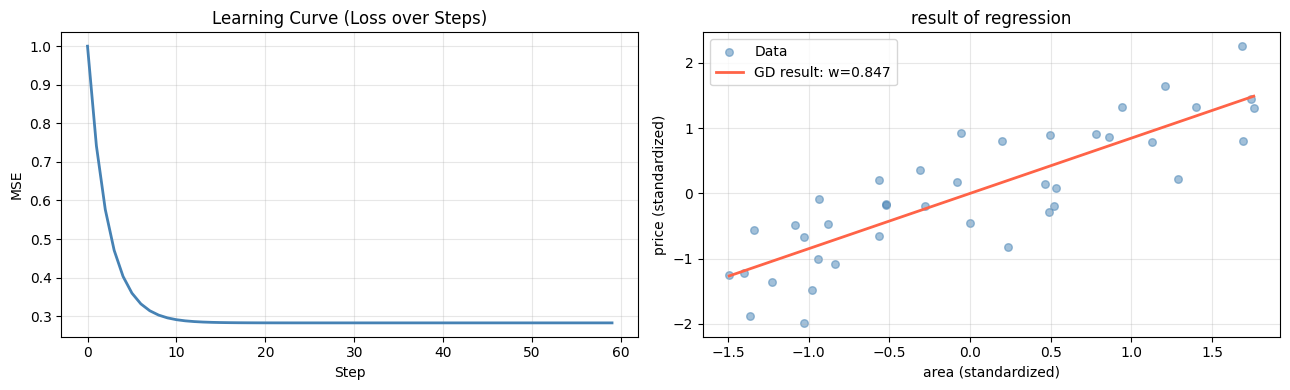

In [7]:
# 학습 곡선 + 회귀선
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist['loss'], color='steelblue', lw=2)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE')
axes[0].set_title('Learning Curve (Loss over Steps)')
axes[0].grid(True, alpha=0.3)

x_line = np.linspace(area_n.min(), area_n.max(), 100)
axes[1].scatter(area_n, price_n, alpha=0.5, s=30, color='steelblue', label='Data')
axes[1].plot(x_line, w_final*x_line+b_final, color='tomato', lw=2,
             label=f'GD result: w={w_final:.3f}')
axes[1].set_xlabel('area (standardized)'); axes[1].set_ylabel('price (standardized)')
axes[1].set_title('result of regression')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

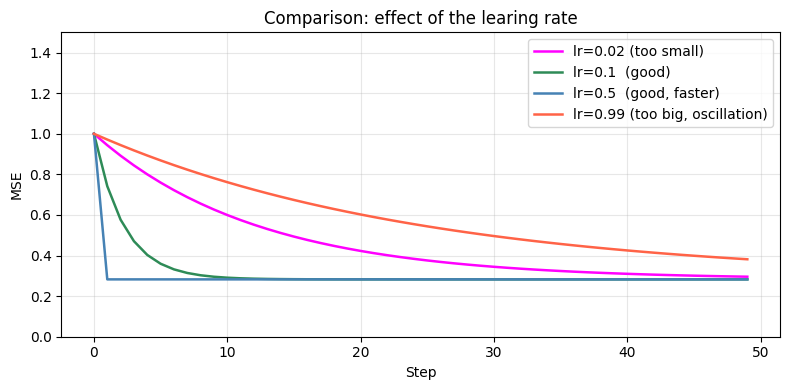

In [8]:
# 학습률 비교
fig, ax = plt.subplots(figsize=(8, 4))
for lr, color, label in [
    (0.02, 'magenta',     'lr=0.02 (too small)'),
    (0.1,  'seagreen', 'lr=0.1  (good)'),
    (0.5,  'steelblue','lr=0.5  (good, faster)'),
    (0.99, 'tomato',   'lr=0.99 (too big, oscillation)'),
]:
    _, _, h = gradient_descent(area_n, price_n, lr=lr, n_steps=50)
    ax.plot(h['loss'], color=color, lw=1.8, label=label)

ax.set_xlabel('Step'); ax.set_ylabel('MSE')
ax.set_title('Comparison: effect of the learing rate')
ax.set_ylim(0, 1.5); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 4. 정규방정식 vs 경사하강법

| |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 정규방정식&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | 경사하강법 |
|---|---|---|
| 방법 | $\mathbf{w}^* = (X^TX)^{-1}X^T\mathbf{y}$ | 반복 업데이트 |
| 결과 | 정확한 최솟값 | 근사값 (반복 횟수에 따라) |
| 계산 비용 | $O(n^3)$ — 특성 수에 매우 민감 | $O(mn)$ × 스텝 수 |
| 딥러닝 | ❌ 사용 불가 | ✅ 핵심 알고리즘 |

두 방법은 같은 최솟값에 수렴합니다.

In [9]:
# 정규방정식 vs 경사하강법 비교
X_mat = np.column_stack([area_n, np.ones(n)])
w_ne  = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ price_n

print("정규방정식 : w={:.6f}, b={:.6f}".format(w_ne[0], w_ne[1]))
print("경사하강법 : w={:.6f}, b={:.6f}".format(w_final, b_final))
print("\n두 방법의 결과가 거의 같습니다 ✓")

정규방정식 : w=0.846988, b=-0.000000
경사하강법 : w=0.846987, b=-0.000000

두 방법의 결과가 거의 같습니다 ✓


---
# ✏️ 익히기 활동 (15분)

교실에서 더 많은 문제를 풀 예정입니다. 여기서는 핵심만 확인합니다.

## 활동 1. Chain rule 적용 (5분)

다음 함수를 $w$에 대해 미분하세요.

**(1)** $f(w) = (2w - 3)^2$ &emsp; → &emsp; $f'(w) = $ ?

**(2)** $f(w) = (wx_i - y_i)^2$ (단, $x_i, y_i$는 상수) &emsp; → &emsp; $f'(w) = $ ?

In [4]:
# 활동 1: 수치 미분으로 손계산 검증
def numerical_deriv(f, w, h=1e-7):
    return (f(w+h) - f(w-h)) / (2*h)

# (1) f(w) = (2w - 3)^2  →  f'(w) = ?
f1     = lambda w: (2*w - 3)**2
df1_my = lambda w: 2 * (2*w - 3) * 2  # 손으로 계산한 결과를 입력하세요

w_test = 1.5
print(f"(1) 수치 미분: {numerical_deriv(f1, w_test):.4f}")
print(f"    손계산:    {df1_my(w_test):.4f}")

# (2) f(w) = (wx - y)^2 with x=2, y=3  →  f'(w) = ?
xi, yi = 2.0, 3.0
f2     = lambda w: (w*xi - yi)**2
df2_my = lambda w: 2*(w*xi-yi)*xi   # 손으로 계산한 결과를 입력하세요

print(f"\n(2) 수치 미분: {numerical_deriv(f2, w_test):.4f}")
print(f"    손계산:    {df2_my(w_test):.4f}")

(1) 수치 미분: 0.0000
    손계산:    0.0000

(2) 수치 미분: 0.0000
    손계산:    0.0000


## 활동 2. 🐛 버그 찾기 (10분)

아래 경사하강법 코드에 버그가 **1개** 있습니다.

In [7]:
# 🐛 Find 2 bugs
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.0, 4.0, 6.0])   # true: y = 2x
w, b, lr = 0.0, 0.0, 0.1

for _ in range(300):
    y_hat = w*x + b
    dw = (2/len(x)) * np.sum((y_hat - y) * x)
    db = (2/len(x)) * np.sum(y_hat - y)
    w  = w - lr*dw   # Bug 1
    b  = b - lr*db

print(f"w={w:.4f}, b={b:.4f}")   # expected: w≈2.0, b≈0.0

w=1.9998, b=0.0005


In [9]:
# ✅ Fixed
w, b = 0.0, 0.0
for _ in range(300):
    y_hat = w*x + b
    dw    = (2/len(x)) * np.sum((y_hat - y) * x)
    db    = (2/len(x)) * np.sum(y_hat - y)
    w     = w - lr*dw
    b     = b - lr*db

print(f"w={w:.4f}, b={b:.4f}")   # expected: w≈2.0, b≈0.0

w=1.9998, b=0.0005


---
# 📋 오늘 배운 것 체크리스트

- [ ] 다항함수 미분 공식을 적용할 수 있다
- [ ] Chain rule: "바깥 미분 × 안 미분" 을 설명할 수 있다
- [ ] $(wx-y)^2$ 를 $w$에 대해 미분하면 $2(wx-y)\cdot x$ 임을 유도할 수 있다
- [ ] 경사하강법 업데이트 식 $w \leftarrow w - \alpha\frac{\partial\mathcal{L}}{\partial w}$의 의미를 설명할 수 있다
- [ ] 학습률이 너무 크거나 작을 때 어떤 문제가 생기는지 설명할 수 있다

---
# 🤖 LLM 파트너 가이드

**① Chain rule 연습:**
```
f(w) = (3w^2 - 2w + 1)^3 을 w에 대해 미분하는 과정을
chain rule을 써서 단계별로 보여줘.
```

**② Gradient 직관:**
```
경사하강법에서 학습률이 너무 크면 왜 발산하는지
이차함수 f(w) = w^2 를 예시로 수식으로 설명해줘.
```

---
# ➡️ 다음 주 예고

**5주차: 다변수 선형회귀**

지금까지는 특성이 1~2개인 경우를 다뤘습니다.  
다음 주에는 특성이 $n$개일 때 gradient를 **벡터**로 표현하고,  
경사하강법이 행렬 연산으로 어떻게 압축되는지 배웁니다.